# Transportable causal bootstrapping: synthetic classification

**A complete demonstration of the `tcb` package, from a selection diagram to deconfounded training samples.**

This notebook refactors `nonIdent_tcb_syn_clas.py`. It retains the original structural causal model, three environments, training/test seeds, sample sizes, linear SVMs, and the full cross-environment evaluation. The handwritten density-ratio and bootstrap routines are replaced by the package's public interfaces.

**Workflow:** identify the transport formula -> inspect the required distributions -> supply source causal knowledge -> fit target densities -> compute TCW -> resample -> train and evaluate.

The default `COUPLING = "product"` follows Chapter 4's complete empirical-product weights. Set it to `"diagonal"` to reproduce the original script's same-row weighting approximation. These two methods can produce different weights and model results. This is a **single seeded demonstration**, not the 30-repeat benchmark.

## 1. Setup and experiment configuration

Open this notebook from the repository's `Demo` folder or launch Jupyter from the repository root. Install the package in the notebook's Python environment first (`python -m pip install .` from the repository root). The demo also needs Jupyter, pandas, and seaborn; `python -m pip install ".[demo]"` installs the optional demo dependencies.

When running from a source checkout, the setup below loads the package from the adjacent `src` directory. The bundled generator makes the demo independent of the original experiment directory. No existing experiment results are read or overwritten.

In [1]:
from pathlib import Path
import sys
import warnings

cwd = Path.cwd().resolve()
ROOT = next((p for p in (cwd, *cwd.parents)
             if (p / "src" / "tcb" / "__init__.py").is_file()
             and (p / "Demo" / "synthetic_classification_data.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the package root or its Demo folder.")
DEMO_DIR = ROOT / "Demo"
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(DEMO_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, Circle
import seaborn as sns
from scipy.special import expit
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from IPython.display import display, Markdown

import tcb
from tcb import (
    Probability, analyze, fit_target_distributions, compute_weights,
    observed_interventions, transportable_bootstrap, ApproximationWarning,
)
from synthetic_classification_data import (
    generate_dataset, SOURCE_PARAMETERS, ENVIRONMENT_SHIFTS,
)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"tcb {tcb.__version__} | Python {sys.version.split()[0]}")

tcb 0.1.0 | Python 3.9.12


In [2]:
ENVS = (0, 1, 2)
TRAIN_N = 4000       # Per environment and regime: 24,000 training rows in total
TEST_N = 1000        # Per environment and regime: 6,000 test rows in total
TRAIN_SEED = 111
TEST_SEED = 222
RESAMPLE_SEED = 20260925
SVM_C = 5.0
SID_MODE = "standard"
COUPLING = "product"  # Use "diagonal" for the original script's approximation
HISTOGRAM_BINS = {"W": 50, "Y": 0, "Z": 0}
SAVE_OUTPUTS = False  # Optional exports go only to Demo/outputs/nonident_classification/

assert COUPLING in {"product", "diagonal"}
config = {
    "train_n_per_subset": TRAIN_N, "test_n_per_subset": TEST_N,
    "train_seed": TRAIN_SEED, "test_seed": TEST_SEED,
    "resample_seed": RESAMPLE_SEED, "svm_c": SVM_C,
    "sid_mode": SID_MODE, "coupling": COUPLING,
    "histogram_bins": HISTOGRAM_BINS,
}
display(pd.Series(config, name="Configuration").to_frame())

,Configuration
train_n_per_subset,4000
test_n_per_subset,1000
train_seed,111
test_seed,222
resample_seed,20260925
svm_c,5.0
sid_mode,standard
coupling,product
histogram_bins,"{'W': 50, 'Y': 0, 'Z': 0}"


## 2. Identify the transport formula

The treatment/label is $Y$, and the outcome $X=(X_1,X_2)$ is represented by a single graph node. Latent variables induce $Y\leftrightarrow Z$ and $Y\leftrightarrow X$. Selection nodes describe changes in the $W$ and $X$ mechanisms across environments.

The effect is not identifiable from target observational data alone in this graph. The source interventional distribution $P(Z\mid\mathrm{do}(Y))$ supplies the additional knowledge needed for transport.

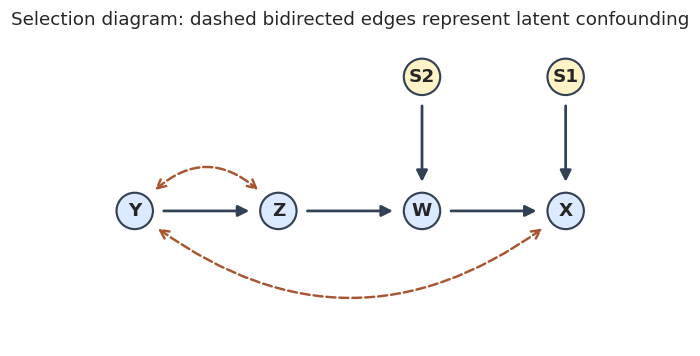

P^{*}\left(X\mid\operatorname{do}(Y)\right) = \sum_{W,Y',Z,Z'}\left[P^{*}\left(X\mid W,Y',Z'\right)\,P^{*}\left(W\mid Y,Z\right)\,P^{*}\left(Y',Z'\right)\,P_{\mathrm{source}}\left(Z\mid \operatorname{do}(Y)\right)\right]
w_n = 1/(N*M) * sum_{j=1..M} [(P_source(Z | do(Y)) * P*(W,Y,Z) * P*(Y',Z')) / (P*(W,Y',Z') * P*(Y,Z) * P*(Z))]; W_X at row n, W_R at row j
W_X = ('W', "Y'", "Z'")
W_R = ('Z',)
Target distributions: P*(W,Y,Z); P*(Y,Z); P*(Z)
Source distributions: P_source(Z | do(Y))
Kernel variables: ()


,domain,distribution
0,source,P_source(Z | do(Y))
1,target,"P*(W,Y,Z)"
2,target,"P*(Y,Z)"
3,target,P*(Z)


In [3]:
SELECTION_DIAGRAM = """Y; Z; W; X; S1; S2;
Y -> Z; Z -> W; W -> X;
Y <-> Z; Y <-> X;
S1 -> X; S2 -> W;"""

positions = {"Y": (0, 0), "Z": (1.5, 0), "W": (3, 0), "X": (4.5, 0),
             "S2": (3, 1.4), "S1": (4.5, 1.4)}
fig_graph, ax = plt.subplots(figsize=(10, 3.4))
for start, end in [("Y", "Z"), ("Z", "W"), ("W", "X"), ("S1", "X"), ("S2", "W")]:
    ax.add_patch(FancyArrowPatch(positions[start], positions[end], arrowstyle="-|>",
                                mutation_scale=15, shrinkA=19, shrinkB=19,
                                linewidth=1.8, color="#334155"))
for end, curvature in [("Z", -0.6), ("X", 0.4)]:
    ax.add_patch(FancyArrowPatch(positions["Y"], positions[end], arrowstyle="<->",
                                connectionstyle=f"arc3,rad={curvature}",
                                mutation_scale=14, shrinkA=19, shrinkB=19,
                                linestyle="--", linewidth=1.6, color="#a85532"))
for name, point in positions.items():
    selection = name.startswith("S")
    ax.add_patch(Circle(point, 0.19, facecolor="#fef3c7" if selection else "#dbeafe",
                        edgecolor="#334155", linewidth=1.4, zorder=3))
    ax.text(*point, name, ha="center", va="center", weight="bold", zorder=4)
ax.set(xlim=(-0.5, 5), ylim=(-1.4, 1.85), aspect="equal")
ax.axis("off")
ax.set_title("Selection diagram: dashed bidirected edges represent latent confounding")
fig_graph.tight_layout()
plt.show()

analysis = analyze(SELECTION_DIAGRAM, outcomes="X", interventions="Y",
                   selection=("S1", "S2"), mode=SID_MODE)
print(analysis.describe())
requirements = pd.DataFrame([
    {"domain": p.domain, "distribution": str(p)}
    for p in analysis.weight_expression.required_distributions
])
display(requirements)

### What the package has derived

For the standard mode, the transport formula is

$$
P^*(X\mid\mathrm{do}(Y=y))=
\int P^*(X\mid W,Y',Z')P^*(Y',Z')P^*(W\mid y,Z)
P(Z\mid\mathrm{do}(y))\,dW\,dY'\,dZ'\,dZ.
$$

The carrier sets are $W_X=\{W,Y',Z'\}$ and $W_R=\{Z\}$. Therefore Chapter 4's observation-level weights are

$$
w_n(y)=\frac{1}{N^2}\sum_{j=1}^{N}
\frac{P^*(w_n\mid y,z_j)P(z_j\mid\mathrm{do}(y))}
     {P^*(w_n\mid y_n,z_n)P^*(z_j)}.
$$

`Y'` and `Z'` refer to the observation at row $n$; the separate `Z` is evaluated at row $j$. The package keeps these scopes distinct. Its symbolic cancellation removes the outcome density, so no density estimation over $(X_1,X_2)$ is required. Binary integration values are grouped with their exact frequencies, preserving the full sum while avoiding an explicit $N\times N$ matrix.

## 3. Supply source causal knowledge

The source distribution is a required **user input**. Here it is known analytically from the synthetic SCM:

$$
q(y)=(1-p_{U_1})\,\sigma(\alpha_Z+\beta_{ZY}(2y-1)-\beta_{ZU_1})
+p_{U_1}\,\sigma(\alpha_Z+\beta_{ZY}(2y-1)+\beta_{ZU_1}),
$$

with $P(Z=1\mid\mathrm{do}(Y=y))=q(y)$. In an application, replace the callback with a valid source experimental or causal model. The target data are not used to estimate this interventional distribution.

In [4]:
def p_z_do_y(points):
    """Vectorized source P(Z | do(Y)); one probability per evaluation row."""
    z, y = points["Z"][:, 0], points["Y"][:, 0]
    p = SOURCE_PARAMETERS
    linear = p["alpha_z"] + p["beta_zy"] * (2*y - 1)
    q = ((1 - p["p_u1"]) * expit(linear - p["beta_zu1"])
         + p["p_u1"] * expit(linear + p["beta_zu1"]))
    return np.where(z == 1, q, np.where(z == 0, 1-q, 0.0))

source_key = Probability("Z", do="Y", domain="source")
source_distributions = {source_key: p_z_do_y}
assert analysis.required_source_distributions == (source_key,)
display(pd.DataFrame({
    "intervention Y": [0, 1],
    "P_source(Z=1 | do(Y))": p_z_do_y({"Z": np.ones((2, 1)), "Y": np.array([[0], [1]])}),
}).set_index("intervention Y"))

,P_source(Z=1 | do(Y))
intervention Y,
0,0.165785
1,0.882999


## 4. Generate training and independent test data

The local generator preserves the original parameters, environment shifts, seeds, and random draw order. Its outputs were checked against the original generator. A local random number generator avoids changing NumPy's global state.

Each environment contains a confounded subset and a non-confounded reference subset. As in the original experiment, the reference regime removes the latent effects into `Y`; it is used to train a benchmark model and to evaluate deconfounding. The latent `U1` and `U2` columns are never passed to the package or classifiers. Training and test generation use separate seeds.

In [5]:
train_df = generate_dataset(TRAIN_N, TRAIN_SEED, ENVS)
test_df = generate_dataset(TEST_N, TEST_SEED, ENVS)

def subset(frame, env, regime):
    return frame.loc[(frame["env"] == env) & (frame["confounded"] == regime)].copy()

def observed_arrays(frame):
    return {"X": frame[["X1", "X2"]].to_numpy(),
            **{v: frame[[v]].to_numpy() for v in ("Y", "Z", "W")}}

assert len(train_df) == len(ENVS) * 2 * TRAIN_N
assert len(test_df) == len(ENVS) * 2 * TEST_N
summary = train_df.groupby(["env", "confounded"]).agg(
    n=("Y", "size"), class_1_fraction=("Y", "mean"),
    mean_X1=("X1", "mean"), mean_W=("W", "mean"),
)
display(summary.round(3))
display(pd.DataFrame.from_dict(ENVIRONMENT_SHIFTS, orient="index").rename_axis("environment"))

n  class_1_fraction  mean_X1  mean_W
env confounded                                             
0   confounded      4000             0.618    0.397   0.750
    non-confounded  4000             0.489    0.044   0.044
1   confounded      4000             0.630    0.423  -0.632
    non-confounded  4000             0.511    0.109  -1.264
2   confounded      4000             0.610    5.416   2.329
    non-confounded  4000             0.498    5.125   1.741

,x1_shift,w_shift,x1_noise,w_noise
environment,,,,
0,0.0,0.0,0.0,0.0
1,0.0,-1.5,0.0,0.2
2,5.0,1.5,0.2,0.2


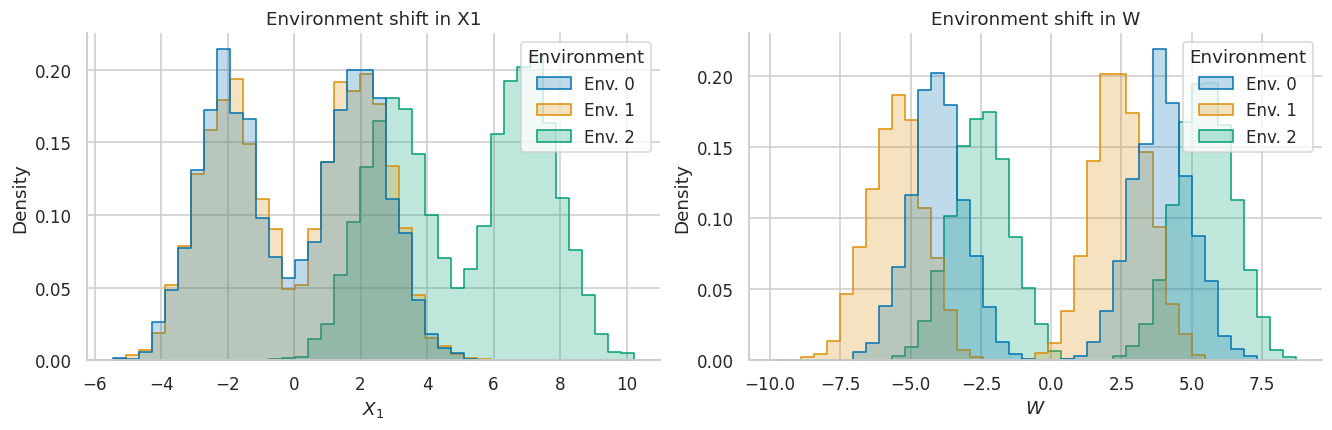

In [6]:
# As in the original script, visualize shifts using the non-confounded reference subsets.
reference = train_df.loc[train_df["confounded"] == "non-confounded"].copy()
reference["Environment"] = reference["env"].map(lambda e: f"Env. {e}")
fig_shift, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for ax, variable, label in zip(axes, ["X1", "W"], [r"$X_1$", r"$W$"]):
    sns.histplot(data=reference, x=variable, hue="Environment", bins=40,
                 element="step", stat="density", common_norm=False, alpha=0.25,
                 palette="colorblind", ax=ax)
    ax.set(title=f"Environment shift in {variable}", xlabel=label, ylabel="Density")
plt.show()

## 5. Fit only the target distributions required by the weights

Each target environment receives its own density estimators, fitted only on its **confounded training subset**. The package reuses `causalbootstrapping` histogram estimators with the original settings: 50 bins for continuous `W`, and category-count bins for binary `Y,Z`.

The same fitted joint is evaluated at observed and intervened values. No test data or non-confounded reference data enter these fits. Histogram values are bin masses, matching the original experiment's convention. A zero denominator raises a support error rather than being silently clipped.

In [7]:
target_data = {env: observed_arrays(subset(train_df, env, "confounded")) for env in ENVS}
target_distributions = {
    env: fit_target_distributions(analysis.weight_expression, target_data[env],
                                 method="histogram", bins=HISTOGRAM_BINS)
    for env in ENVS
}
print("Target distributions fitted independently in all three environments:")
for distribution in analysis.required_target_distributions:
    print(" -", distribution)

Target distributions fitted independently in all three environments:
 - P*(W,Y,Z)
 - P*(Y,Z)
 - P*(Z)


## 6. Inspect causal weights before sampling

The low-level interface exposes both normalized sampling probabilities and raw log weights. Effective sample size (ESS) measures weight concentration, not causal validity. Below, the full-product and historical diagonal weights are compared using exactly the same data and density estimates; they need not agree.

diagonal: diagonal coupling uses same-row particles. It is the older experiment approximation, not Chapter 4's full empirical-product TCW.


,ESS,ESS / N,maximum probability,zero weights
coupling,,,,
product,2775.83561,0.69396,0.00109,21
diagonal,2961.57432,0.74039,0.00105,21


L1 distance between normalized weights: 0.0717


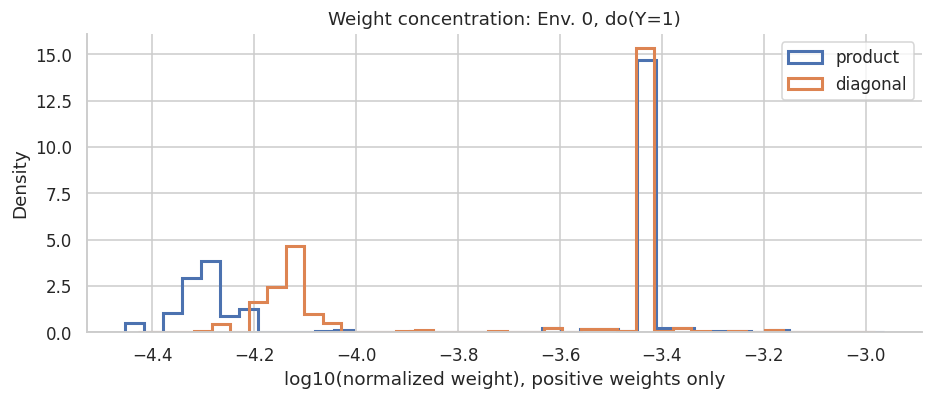

In [8]:
example_env, example_intervention = 0, {"Y": 1}
example_weights = compute_weights(
    analysis.weight_expression, target_data[example_env], example_intervention,
    source_distributions=source_distributions,
    target_distributions=target_distributions[example_env], coupling=COUPLING,
)

comparison_rows = []
comparison_weights = {}
for coupling in ("product", "diagonal"):
    with warnings.catch_warnings(record=True) as notices:
        warnings.simplefilter("always", ApproximationWarning)
        result = compute_weights(
            analysis.weight_expression, target_data[example_env], example_intervention,
            source_distributions=source_distributions,
            target_distributions=target_distributions[example_env], coupling=coupling,
        )
    comparison_weights[coupling] = result.weights
    comparison_rows.append({"coupling": coupling, "ESS": result.effective_sample_size,
                            "ESS / N": result.effective_sample_size / TRAIN_N,
                            "maximum probability": result.weights.max(),
                            "zero weights": int(np.sum(result.weights == 0))})
    for notice in notices:
        print(f"{coupling}: {notice.message}")
display(pd.DataFrame(comparison_rows).set_index("coupling").round(5))
print("L1 distance between normalized weights:",
      round(float(np.abs(comparison_weights["product"] - comparison_weights["diagonal"]).sum()), 4))

fig_weights, ax = plt.subplots(figsize=(8.5, 3.8))
for coupling, values in comparison_weights.items():
    positive = values[values > 0]
    ax.hist(np.log10(positive), bins=40, density=True, histtype="step", linewidth=2, label=coupling)
ax.set(xlabel="log10(normalized weight), positive weights only", ylabel="Density",
       title="Weight concentration: Env. 0, do(Y=1)")
ax.legend()
fig_weights.tight_layout()
plt.show()

## 7. Bootstrap and train three model groups

`transportable_bootstrap` computes weights and resamples for both intervention values. `observed_interventions` preserves the original class counts in each environment. All arrays use shared sample indices; the new training labels are **`intv_Y`**, not the retained observational `Y`.

For every environment, train a linear SVM (`C=5`) on: (1) confounded observations, (2) TCB samples, and (3) non-confounded reference observations. Resampling uses a fixed seed per environment. Numerical results may differ from the old unseeded sampling run even under diagonal coupling.

In [9]:
MODEL_ORDER = ("Confounded", "TCB", "Non-confounded reference")
models = {name: {} for name in MODEL_ORDER}
training_sets = {name: {} for name in MODEL_ORDER}
tcb_results, diagnostic_rows = {}, []

for env in ENVS:
    interventions, counts = observed_interventions(target_data[env], "Y")
    seed = int(np.random.SeedSequence([RESAMPLE_SEED, env]).generate_state(1)[0])
    result = transportable_bootstrap(
        analysis, target_data[env], interventions,
        source_distributions=source_distributions,
        target_distributions=target_distributions[env],
        sample_counts=counts, coupling=COUPLING, random_state=seed,
    )
    tcb_results[env] = result
    assert len(result.indices) == TRAIN_N
    np.testing.assert_array_equal(result.data["X"], target_data[env]["X"][result.indices])
    for intervention, count, weight_result in zip(interventions, counts, result.weight_results):
        label = int(np.asarray(intervention["Y"]).item())
        assert int(np.sum(result.data["intv_Y"] == label)) == count
        diagnostic_rows.append({"environment": env, "do(Y)": label, "samples": count,
                                "ESS": weight_result.effective_sample_size,
                                "ESS / N": weight_result.effective_sample_size / TRAIN_N,
                                "max probability": weight_result.probabilities.max()})
    nonconf = subset(train_df, env, "non-confounded")
    training_sets["Confounded"][env] = (target_data[env]["X"], target_data[env]["Y"].ravel())
    training_sets["TCB"][env] = (result.data["X"], result.data["intv_Y"].ravel())
    training_sets["Non-confounded reference"][env] = (nonconf[["X1", "X2"]].to_numpy(), nonconf["Y"].to_numpy())
    for name in MODEL_ORDER:
        x, y = training_sets[name][env]
        models[name][env] = SVC(kernel="linear", C=SVM_C, random_state=seed).fit(x, y)
    print(f"Env. {env}: bootstrapped {len(result.indices):,} samples and fitted three SVMs.")

weight_diagnostics = pd.DataFrame(diagnostic_rows)
display(weight_diagnostics.round(4))

Env. 0: bootstrapped 4,000 samples and fitted three SVMs.


Env. 1: bootstrapped 4,000 samples and fitted three SVMs.


Env. 2: bootstrapped 4,000 samples and fitted three SVMs.


,environment,do(Y),samples,ESS,ESS / N,max probability
0,0,0,1530,2506.4467,0.6266,0.0009
1,0,1,2470,2775.8356,0.6940,0.0011
2,1,0,1480,2476.1659,0.6190,0.0016
3,1,1,2520,2803.9959,0.7010,0.0011
4,2,0,1559,2506.2041,0.6266,0.0015
5,2,1,2441,2805.5480,0.7014,0.0011


## 8. Evaluate all train/test environment pairs

The evaluation contains **3 training environments x 3 test environments x 3 model groups x 2 test regimes = 54 accuracy records**. The test dataset is generated independently and is never used for density estimation or training.

The intended target is deconfounding **within a specified environment**. A model trained for one environment is not guaranteed to transfer unchanged when the outcome mechanism shifts in another environment. Accuracy on confounded test data answers a different question from recovery of the causal relationship.

In [10]:
evaluation_rows = []
for train_env in ENVS:
    for test_env in ENVS:
        for name in MODEL_ORDER:
            for regime in ("confounded", "non-confounded"):
                frame = subset(test_df, test_env, regime)
                prediction = models[name][train_env].predict(frame[["X1", "X2"]].to_numpy())
                evaluation_rows.append({"train_env": train_env, "test_env": test_env,
                                        "model": name, "test_subset": regime,
                                        "accuracy": accuracy_score(frame["Y"], prediction)})
results = pd.DataFrame(evaluation_rows)
assert len(results) == 54
assert not results.duplicated(["train_env", "test_env", "model", "test_subset"]).any()
assert results["accuracy"].between(0, 1).all()
within_environment = results.loc[
    (results["train_env"] == results["test_env"]) & (results["test_subset"] == "non-confounded")
].pivot(index="test_env", columns="model", values="accuracy").reindex(columns=MODEL_ORDER)
display((100 * within_environment).round(2).rename_axis("environment").rename_axis("accuracy (%)", axis=1))

accuracy (%),Confounded,TCB,Non-confounded reference
environment,,,
0,76.8,83.9,84.1
1,75.2,83.2,83.9
2,76.1,84.7,84.8


## 9. Decision boundaries and cross-environment accuracy

The decision boundaries are drawn as zero contours of the fitted decision functions, which also handles nearly vertical boundaries. Class labels are correctly displayed as `0` and `1`. The dashed vertical line is the SCM's environment-dependent `X1` location reference (0, 0, 5), and the dotted horizontal line marks the latent-feature split at `X2=0`; neither is asserted to be the exact Bayes decision boundary.

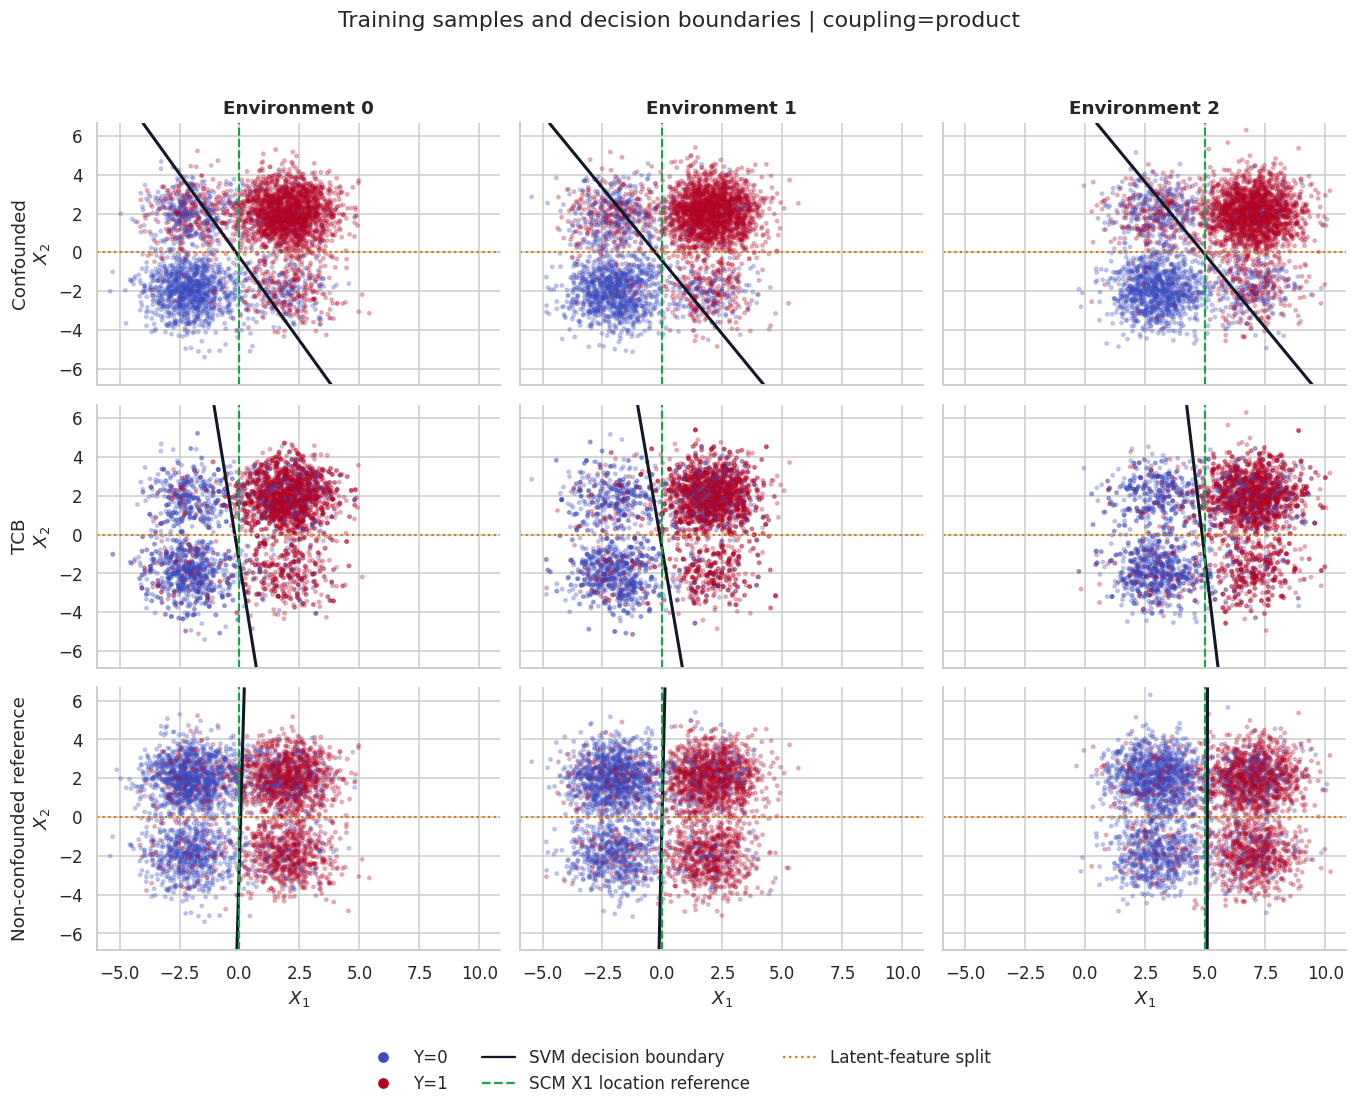

In [11]:
limits = {}
for column in ("X1", "X2"):
    values = np.concatenate([train_df[column].to_numpy(), test_df[column].to_numpy()])
    pad = 0.03 * np.ptp(values)
    limits[column] = (values.min() - pad, values.max() + pad)
gx, gy = np.meshgrid(np.linspace(*limits["X1"], 160), np.linspace(*limits["X2"], 160))
grid = np.column_stack([gx.ravel(), gy.ravel()])
fig_boundaries, axes = plt.subplots(3, 3, figsize=(12.5, 10), sharex=True, sharey=True)
for row, name in enumerate(MODEL_ORDER):
    for col, env in enumerate(ENVS):
        ax = axes[row, col]
        x, y = training_sets[name][env]
        ax.scatter(x[:, 0], x[:, 1], c=y, cmap="coolwarm", vmin=0, vmax=1,
                   s=5, alpha=0.25, rasterized=True)
        surface = models[name][env].decision_function(grid).reshape(gx.shape)
        ax.contour(gx, gy, surface, levels=[0], colors=["#111827"], linewidths=2)
        ax.axvline(ENVIRONMENT_SHIFTS[env]["x1_shift"], color="#16a34a", linestyle="--", linewidth=1.4)
        ax.axhline(0, color="#d97706", linestyle=":", linewidth=1.4)
        ax.set(xlim=limits["X1"], ylim=limits["X2"])
        if row == 0:
            ax.set_title(f"Environment {env}", weight="bold")
        if col == 0:
            ax.set_ylabel(name + "\n" + r"$X_2$")
        if row == 2:
            ax.set_xlabel(r"$X_1$")
handles = [Line2D([], [], marker="o", linestyle="", color=plt.cm.coolwarm(0.0), label="Y=0"),
           Line2D([], [], marker="o", linestyle="", color=plt.cm.coolwarm(1.0), label="Y=1"),
           Line2D([], [], color="#111827", label="SVM decision boundary"),
           Line2D([], [], color="#16a34a", linestyle="--", label="SCM X1 location reference"),
           Line2D([], [], color="#d97706", linestyle=":", label="Latent-feature split")]
fig_boundaries.legend(handles=handles, loc="lower center", ncol=3, frameon=False)
fig_boundaries.suptitle(f"Training samples and decision boundaries | coupling={COUPLING}", y=0.995)
fig_boundaries.tight_layout(rect=[0, 0.07, 1, 0.97])
plt.show()

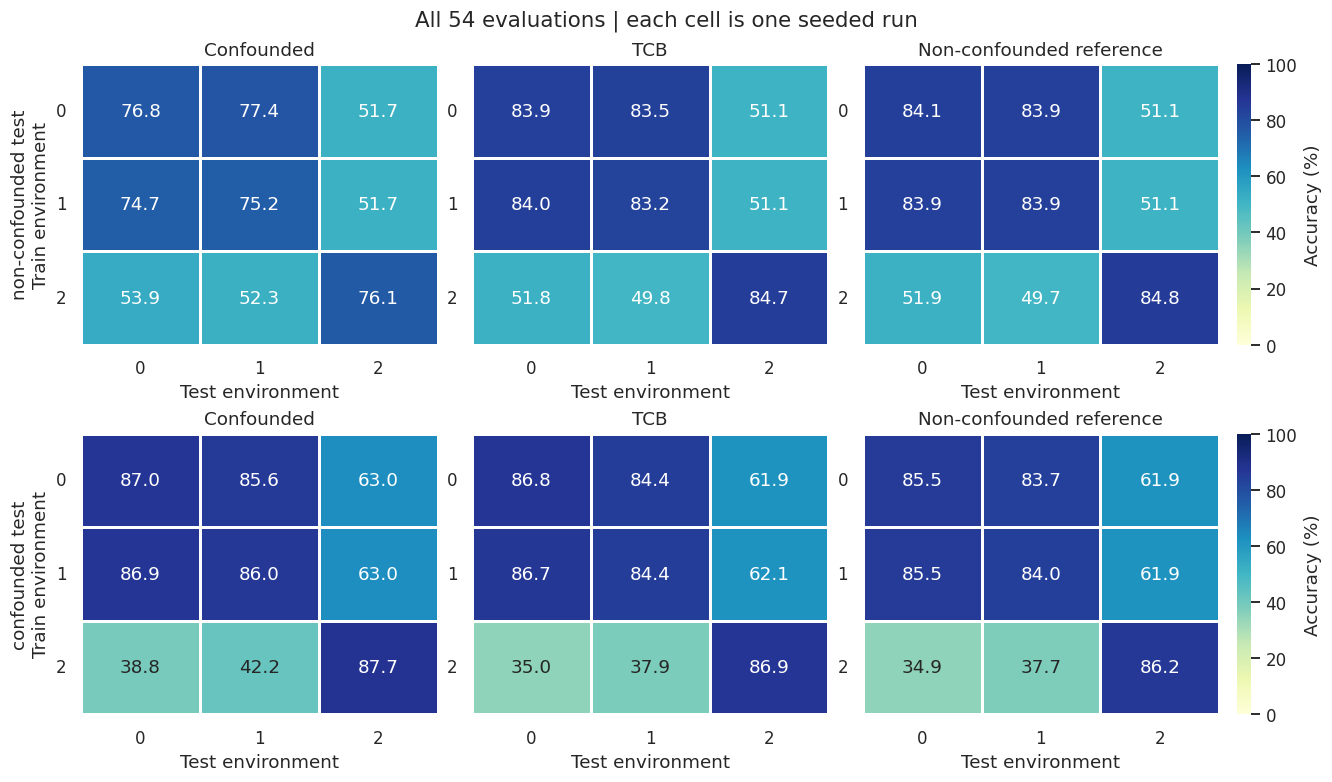

In [12]:
fig_accuracy, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for row, regime in enumerate(("non-confounded", "confounded")):
    for col, name in enumerate(MODEL_ORDER):
        ax = axes[row, col]
        matrix = results.loc[(results["model"] == name) & (results["test_subset"] == regime)].pivot(
            index="train_env", columns="test_env", values="accuracy").reindex(index=ENVS, columns=ENVS)
        sns.heatmap(100 * matrix, ax=ax, annot=True, fmt=".1f", cmap="YlGnBu",
                    vmin=0, vmax=100, cbar=(col == 2),
                    cbar_kws={"label": "Accuracy (%)"}, linewidths=0.8)
        ax.set_title(name)
        ax.set_xlabel("Test environment")
        ax.set_ylabel(f"{regime} test\nTrain environment" if col == 0 else "")
        ax.tick_params(axis="y", rotation=0)
fig_accuracy.suptitle("All 54 evaluations | each cell is one seeded run", fontsize=14)
plt.show()

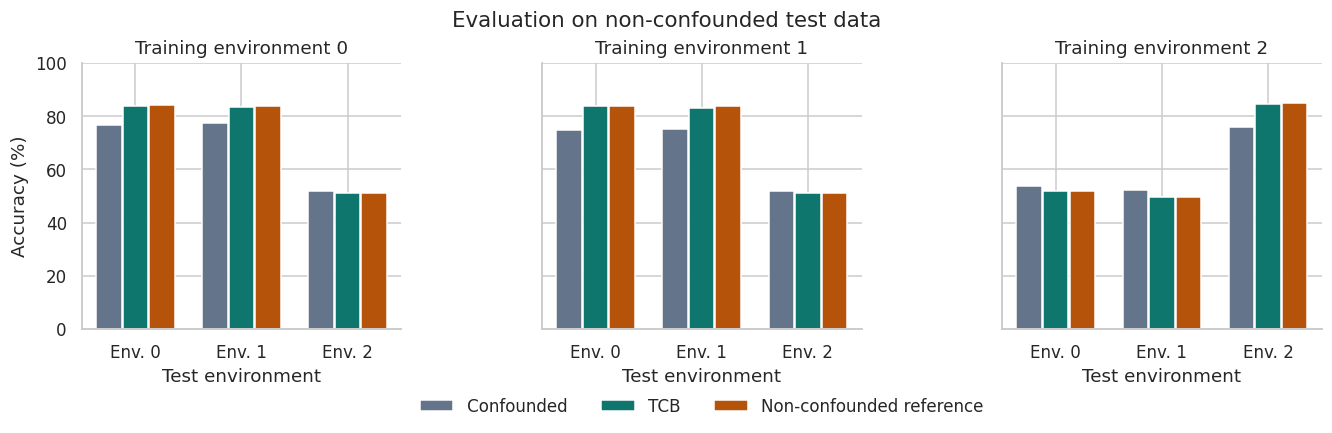

In [13]:
nonconf_results = results.loc[results["test_subset"] == "non-confounded"]
fig_bars, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True, constrained_layout=True)
colors = ["#64748b", "#0f766e", "#b45309"]
for ax, train_env in zip(axes, ENVS):
    for offset, (name, color) in enumerate(zip(MODEL_ORDER, colors)):
        values = nonconf_results.loc[(nonconf_results["train_env"] == train_env)
                                     & (nonconf_results["model"] == name)].set_index("test_env").loc[list(ENVS), "accuracy"]
        ax.bar(np.arange(3) + (offset - 1)*0.25, 100*values.to_numpy(), width=0.24,
               color=color, label=name)
    ax.set(xticks=np.arange(3), xticklabels=[f"Env. {e}" for e in ENVS],
           ylim=(0, 100), xlabel="Test environment", title=f"Training environment {train_env}")
axes[0].set_ylabel("Accuracy (%)")
fig_bars.suptitle("Evaluation on non-confounded test data", fontsize=14)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
plt.show()

### Implementation references

- `../src/tcb/workflows.py`: graph analysis and the high-level bootstrap workflow.
- `../src/tcb/backend.py`: TCW evaluation, normalization, ESS, and shared-index resampling.
- `../src/tcb/density.py`: target density estimation and callback adapters.
- `../docs/theory.md`: correspondence with `ch4.tex`, including full-product versus diagonal coupling.
- `synthetic_classification_data.py`: portable version of the original experiment's SCM.

The notebook contains no handwritten TCB weight implementation and does not import or execute the original experiment script.